<a href="https://colab.research.google.com/github/AnuragTiwari-hub/AIML/blob/main/AIML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files
uploaded = files.upload()


Saving Housing.csv to Housing.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score


In [3]:
# Load dataset
data = pd.read_csv("Housing.csv")

# Display first 5 rows
print(data.head())


      price  area  bedrooms  bathrooms  stories mainroad guestroom basement  \
0  13300000  7420         4          2        3      yes        no       no   
1  12250000  8960         4          4        4      yes        no       no   
2  12250000  9960         3          2        2      yes        no      yes   
3  12215000  7500         4          2        2      yes        no      yes   
4  11410000  7420         4          1        2      yes       yes      yes   

  hotwaterheating airconditioning  parking prefarea furnishingstatus  
0              no             yes        2      yes        furnished  
1              no             yes        3       no        furnished  
2              no              no        2      yes   semi-furnished  
3              no             yes        3      yes        furnished  
4              no             yes        2       no        furnished  


In [4]:
# Convert categorical values to numeric
binary_cols = ['mainroad', 'guestroom', 'basement',
               'hotwaterheating', 'airconditioning', 'prefarea']

for col in binary_cols:
    data[col] = data[col].map({'yes': 1, 'no': 0})

# Convert furnishingstatus
data = pd.get_dummies(data, columns=['furnishingstatus'], drop_first=True)

print(data.head())


      price  area  bedrooms  bathrooms  stories  mainroad  guestroom  \
0  13300000  7420         4          2        3         1          0   
1  12250000  8960         4          4        4         1          0   
2  12250000  9960         3          2        2         1          0   
3  12215000  7500         4          2        2         1          0   
4  11410000  7420         4          1        2         1          1   

   basement  hotwaterheating  airconditioning  parking  prefarea  \
0         0                0                1        2         1   
1         0                0                1        3         0   
2         1                0                0        2         1   
3         1                0                1        3         1   
4         1                0                1        2         0   

   furnishingstatus_semi-furnished  furnishingstatus_unfurnished  
0                            False                         False  
1                       

In [5]:
X = data.drop('price', axis=1)   # Features
y = data['price']               # Target

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [6]:
model = LinearRegression()
model.fit(X_train, y_train)


LinearRegression()

In [7]:
y_pred = model.predict(X_test)


In [8]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("R2 Score:", r2)


Mean Squared Error: 1754318687330.6633
R2 Score: 0.6529242642153185


In [9]:
import numpy as np
import pandas as pd

# Define the column names based on the training data (X.columns)
feature_columns = ['area', 'bedrooms', 'bathrooms', 'stories', 'mainroad', 'guestroom',
                   'basement', 'hotwaterheating', 'airconditioning', 'parking', 'prefarea',
                   'furnishingstatus_semi-furnished', 'furnishingstatus_unfurnished']

# Example new house data (assuming 'furnished', so both one-hot encoded columns are 0)
# The original array was missing the two 'furnishingstatus' columns.
# New array has 13 features to match the model's expectation.
new_house_values = [[7420, 4, 2, 3, 1, 0, 1, 1, 0, 1, 0, 0, 0]]

# Convert to a DataFrame with appropriate column names
new_house_df = pd.DataFrame(new_house_values, columns=feature_columns)

predicted_price = model.predict(new_house_df)
print("Predicted House Price:", predicted_price[0])

Predicted House Price: 7397017.973474091


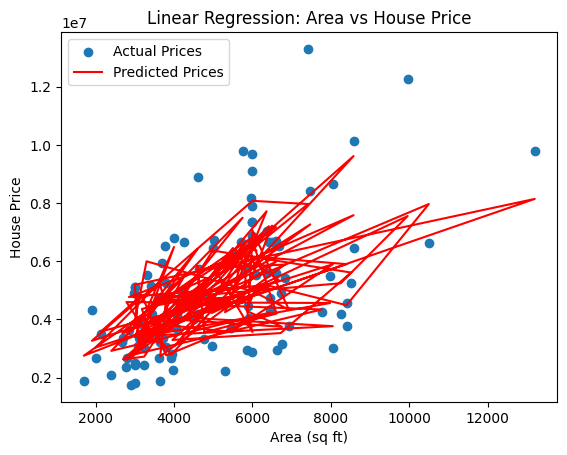

In [10]:
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
plt.figure()
plt.scatter(X_test['area'], y_test, label='Actual Prices')
plt.plot(X_test['area'], y_pred, color='red', label='Predicted Prices')
plt.xlabel("Area (sq ft)")
plt.ylabel("House Price")
plt.title("Linear Regression: Area vs House Price")
plt.legend()
plt.show()